In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
 
%matplotlib inline
sns.set(style="whitegrid")


In [2]:
df = pd.read_csv("../data/retail_store_sales_cleaned.csv", parse_dates=["transaction_date"])
print("Shape:", df.shape)
print("Date range:", df["transaction_date"].min(), "to", df["transaction_date"].max())
df.head()


Shape: (12575, 11)
Date range: 2022-01-01 00:00:00 to 2025-01-18 00:00:00


,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,discount_applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9,247.5,Credit Card,Online,2022-05-07,False
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7,87.5,Digital Wallet,Online,2022-10-02,False


In [3]:
daily = (
    df.groupby("transaction_date")
      .agg(
          total_sales=("total_spent", "sum"),
          total_quantity=("quantity", "sum"),
          avg_price=("price_per_unit", "mean"),
          transaction_count=("transaction_id", "count"),
      )
      .reset_index()
      .sort_values("transaction_date")
      .reset_index(drop=True)
)
 
print("Daily rows:", daily.shape)
daily.head()


Daily rows: (1114, 5)


,transaction_date,total_sales,total_quantity,avg_price,transaction_count
0,2022-01-01,1642.5,69,22.727273,11
1,2022-01-02,1135.5,39,27.875000,8
2,2022-01-03,823.0,44,21.500000,8
3,2022-01-04,1117.5,42,27.125000,8
4,2022-01-05,2347.5,87,26.321429,14


In [4]:
daily["year"] = daily["transaction_date"].dt.year
daily["month"] = daily["transaction_date"].dt.month
daily["day"] = daily["transaction_date"].dt.day
daily["day_of_week"] = daily["transaction_date"].dt.dayofweek   # 0=Monday
daily["is_weekend"] = (daily["day_of_week"] >= 5).astype(int)
 
daily.head()


,transaction_date,total_sales,total_quantity,avg_price,transaction_count,year,month,day,day_of_week,is_weekend
0,2022-01-01,1642.5,69,22.727273,11,2022,1,1,5,1
1,2022-01-02,1135.5,39,27.875000,8,2022,1,2,6,1
2,2022-01-03,823.0,44,21.500000,8,2022,1,3,0,0
3,2022-01-04,1117.5,42,27.125000,8,2022,1,4,1,0
4,2022-01-05,2347.5,87,26.321429,14,2022,1,5,2,0


In [5]:
daily["sales_lag_1"] = daily["total_sales"].shift(1)
daily["sales_lag_7"] = daily["total_sales"].shift(7)
daily["sales_rolling_7"] = daily["total_sales"].rolling(window=7).mean()
daily["sales_rolling_30"] = daily["total_sales"].rolling(window=30).mean()
 
daily[["transaction_date", "total_sales", "sales_lag_1", "sales_lag_7",
       "sales_rolling_7", "sales_rolling_30"]].tail(10)


,transaction_date,total_sales,sales_lag_1,sales_lag_7,sales_rolling_7,sales_rolling_30
1104,2025-01-09,1417.0,2536.5,1946.0,1616.357143,1650.916667
1105,2025-01-10,1323.5,1417.0,2419.0,1459.857143,1628.800000
1106,2025-01-11,1277.0,1323.5,2187.0,1329.857143,1615.083333
1107,2025-01-12,1586.0,1277.0,743.5,1450.214286,1592.700000
1108,2025-01-13,1048.5,1586.0,1514.5,1383.642857,1582.300000
1109,2025-01-14,1304.0,1048.5,497.0,1498.928571,1578.600000
1110,2025-01-15,1081.0,1304.0,2536.5,1291.000000,1560.683333
1111,2025-01-16,1506.5,1081.0,1417.0,1303.785714,1577.016667
1112,2025-01-17,1386.0,1506.5,1323.5,1312.714286,1607.350000
1113,2025-01-18,1124.0,1386.0,1277.0,1290.857143,1606.950000


In [6]:
print("Rows before dropna:", len(daily))
daily = daily.dropna().reset_index(drop=True)
print("Rows after dropna:", len(daily))
 
daily.isnull().sum()


Rows before dropna: 1114
Rows after dropna: 1085


transaction_date     0
total_sales          0
total_quantity       0
avg_price            0
transaction_count    0
year                 0
month                0
day                  0
day_of_week          0
is_weekend           0
sales_lag_1          0
sales_lag_7          0
sales_rolling_7      0
sales_rolling_30     0
dtype: int64

In [7]:
feature_cols = [
    "year", "month", "day", "day_of_week", "is_weekend",
    "sales_lag_1", "sales_lag_7", "sales_rolling_7", "sales_rolling_30",
    "transaction_count", "total_quantity", "avg_price",
]
target_col = "total_sales"
 
split_idx = int(len(daily) * 0.8)
train = daily.iloc[:split_idx]
test = daily.iloc[split_idx:]
 
X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]
 
print("Train rows:", len(train), "| Test rows:", len(test))
print("Train period:", train["transaction_date"].min(), "to", train["transaction_date"].max())
print("Test period:", test["transaction_date"].min(), "to", test["transaction_date"].max())


Train rows: 868 | Test rows: 217
Train period: 2022-01-30 00:00:00 to 2024-06-15 00:00:00
Test period: 2024-06-16 00:00:00 to 2025-01-18 00:00:00


In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)
 
y_pred_lr = lr.predict(X_test)
print("Linear Regression trained.")


Linear Regression trained.


In [9]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
 
y_pred_rf = rf.predict(X_test)
print("Random Forest trained.")


Random Forest trained.


In [11]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "RMSE": round(rmse, 2), "MAE": round(mae, 2), "R2": round(r2, 3)}
 
results = pd.DataFrame([
    evaluate(y_test, y_pred_lr, "Linear Regression"),
    evaluate(y_test, y_pred_rf, "Random Forest"),
])
results

,Model,RMSE,MAE,R2
0,Linear Regression,112.39,88.98,0.942
1,Random Forest,110.73,89.08,0.943


C:\Users\samru\AppData\Local\Temp\ipykernel_355216\295466400.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


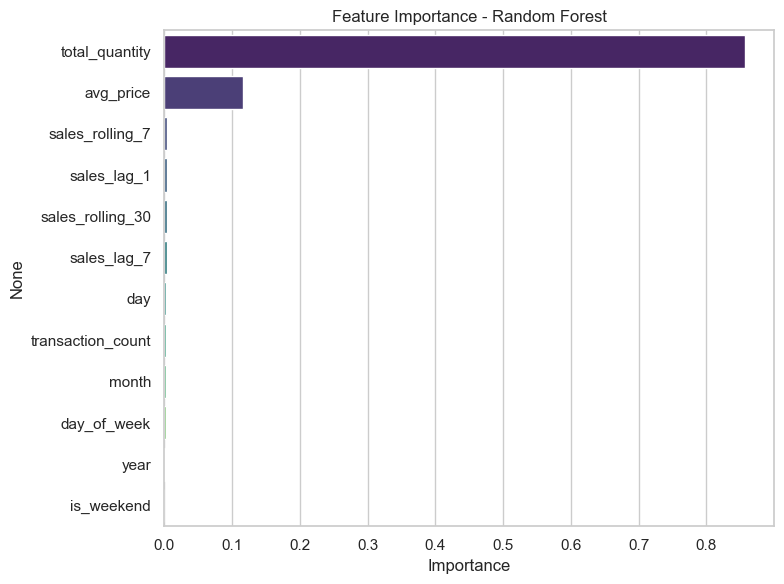

total_quantity       0.856903
avg_price            0.115539
sales_rolling_7      0.004283
sales_lag_1          0.004066
sales_rolling_30     0.003751
sales_lag_7          0.003536
day                  0.003266
transaction_count    0.002545
month                0.002517
day_of_week          0.001859
year                 0.001466
is_weekend           0.000269
dtype: float64

In [14]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
 
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../screenshots/10_Random_Forest.png", dpi=150, bbox_inches="tight")
plt.show()
 
importances


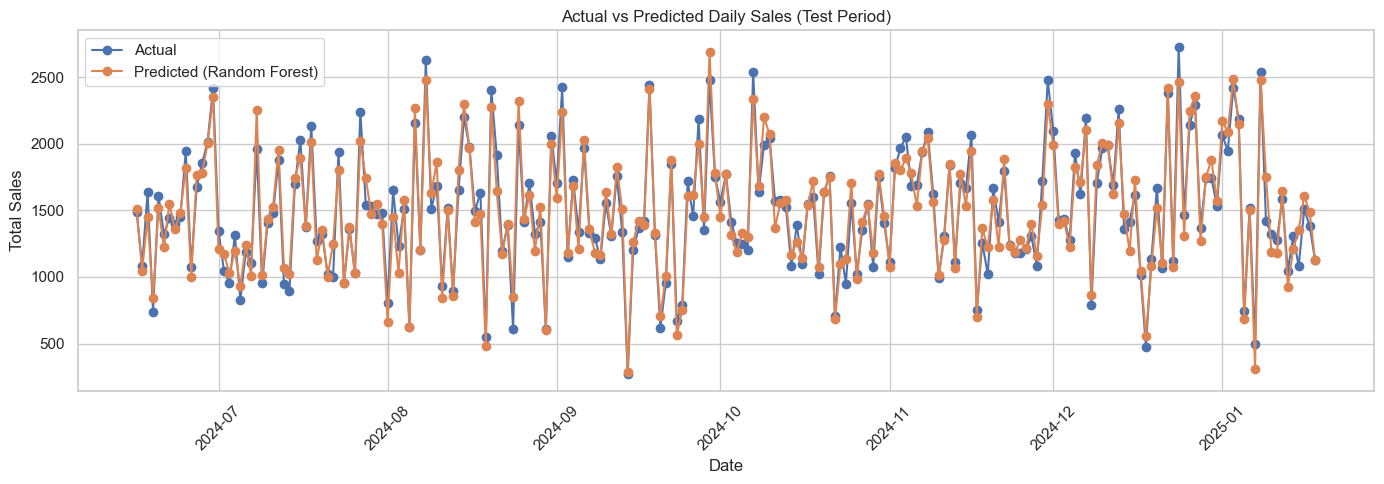

In [16]:
plt.figure(figsize=(14, 5))
plt.plot(test["transaction_date"], y_test.values, label="Actual", marker="o")
plt.plot(test["transaction_date"], y_pred_rf, label="Predicted (Random Forest)", marker="o")
plt.title("Actual vs Predicted Daily Sales (Test Period)")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("../screenshots/11_Actual_vs_Predicted_Daily_Sales.png", dpi=150, bbox_inches="tight")
plt.show()


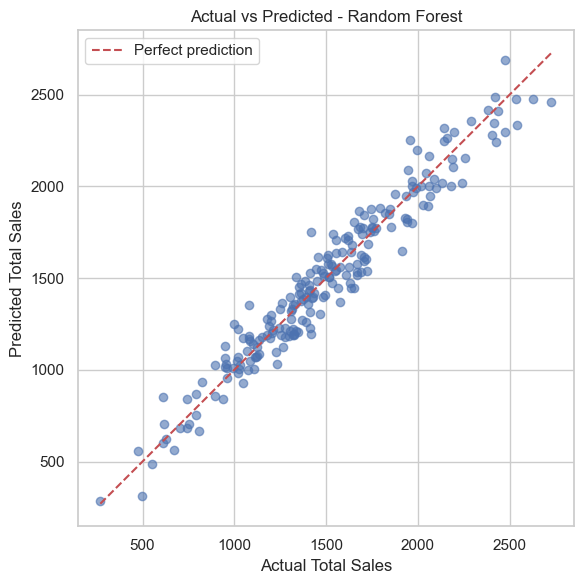

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color="#4C72B0")
lims = [min(y_test.min(), y_pred_rf.min()), max(y_test.max(), y_pred_rf.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual Total Sales")
plt.ylabel("Predicted Total Sales")
plt.title("Actual vs Predicted - Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig("../screenshots/12_Actual_vs_Predicted_Random_Forest.png", dpi=150, bbox_inches="tight")
plt.show()


In [18]:
from sklearn.model_selection import TimeSeriesSplit
 
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
}
 
tscv = TimeSeriesSplit(n_splits=5)
 
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
grid.fit(X_train, y_train)
 
print("Best parameters:", grid.best_params_)


Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}


In [19]:
best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test)
 
results = pd.concat([
    results,
    pd.DataFrame([evaluate(y_test, y_pred_best, "Tuned Random Forest")])
], ignore_index=True)
 
results


,Model,RMSE,MAE,R2
0,Linear Regression,112.39,88.98,0.942
1,Random Forest,110.73,89.08,0.943
2,Tuned Random Forest,110.71,89.44,0.943


In [24]:
df['total_spent'].mean()

130.03693836978132

# Model Performance Analysis and Business Interpretation

## 1. Model Comparison

Three regression models were evaluated to predict sales performance: Linear Regression, Random Forest, and a Tuned Random Forest model.

| Model               | RMSE   | MAE   | R²    |
| ------------------- | ------ | ----- | ----- |
| Linear Regression   | 112.39 | 88.98 | 0.942 |
| Random Forest       | 110.73 | 89.08 | 0.943 |
| Tuned Random Forest | 110.71 | 89.44 | 0.943 |

The **Tuned Random Forest** achieved the best overall performance with the lowest RMSE value of **110.71** and the highest R² score of **0.943**. However, the improvement over the standard Random Forest model was minimal, indicating that the original Random Forest model was already highly optimized.

Compared to Linear Regression, the Tuned Random Forest reduced prediction error by approximately **1.5%** while maintaining a very high explanatory power. All three models achieved R² values above **94%**, indicating that they successfully captured most of the variation in sales.

---

## 2. Key Drivers of Sales Prediction

The feature importance analysis revealed the following key predictors:

| Feature          | Importance |
| ---------------- | ---------- |
| total_quantity   | 85.69%     |
| avg_price        | 11.55%     |
| sales_rolling_7  | 0.43%      |
| sales_lag_1      | 0.41%      |
| sales_rolling_30 | 0.38%      |
| sales_lag_7      | 0.35%      |

The most influential feature was **total_quantity**, contributing approximately **85.7%** of the model's predictive power. This is expected because sales revenue is directly related to the number of units sold.

The second most important feature was **avg_price** with an importance of **11.6%**. Product pricing has a direct impact on transaction value, making it a strong driver of total sales.

Historical trend indicators such as **sales_rolling_7**, **sales_lag_1**, **sales_rolling_30**, and **sales_lag_7** contributed smaller but meaningful amounts to the prediction process. These variables help the model identify recent sales momentum and recurring demand patterns.

Overall, the results indicate that sales performance is primarily influenced by product quantity and pricing, while historical sales trends provide additional forecasting information.

---

## 3. Model Accuracy in Business Context

The average transaction sales value in the dataset was approximately **130.04 units**.

The Tuned Random Forest model achieved:

* **RMSE = 110.71**
* **MAE = 89.44**

Expressed as a percentage of the average sales value:

* **RMSE = 85.13% of average sales**
* **MAE = 68.78% of average sales**

This means that the model's predictions differ from actual sales by approximately **89 units on average**. While the model explains a large proportion of sales variation (R² = 94.3%), the relatively high error percentages indicate that individual transaction values can vary significantly. Therefore, the model is more suitable for identifying overall sales patterns and trends than for perfectly predicting every individual transaction.

---

## 4. Business Interpretation

The developed sales prediction model can support several business operations and planning activities, including:

* Forecasting future sales demand.
* Inventory and stock management.
* Workforce and staffing planning.
* Revenue forecasting and budgeting.
* Identifying short-term sales trends.

For example, managers can use the model to estimate upcoming sales volumes and adjust inventory purchases accordingly. This can help reduce stock shortages, prevent overstocking, and improve operational efficiency.

The model is particularly useful for forecasting sales based on recent historical trends. However, it may not fully capture sudden demand changes caused by promotional campaigns, holidays, competitor actions, supply chain disruptions, or unexpected market events.

---

## 5. Limitations and Future Improvements

Although the model achieved strong predictive performance, several limitations should be acknowledged:

* The dataset contains a limited amount of historical data.
* The model has not been tested across multiple years of seasonal patterns.
* External factors such as promotions, holidays, weather conditions, and economic indicators were not included.
* Prediction accuracy may decrease during periods of unusual demand or market disruptions.

Future work could focus on:

1. Collecting additional historical sales data across multiple years.
2. Incorporating promotional, holiday, and seasonal indicators.
3. Building category-level forecasting models.
4. Developing location-specific sales prediction models.
5. Evaluating advanced machine learning algorithms such as XGBoost and LightGBM.

Overall, the Tuned Random Forest model demonstrated the strongest performance, explaining approximately **94.3%** of the variation in sales and providing valuable insights for data-driven business decision-making.
